<a href="https://colab.research.google.com/github/marianoInsa/dimiasa-models/blob/main/notebooks/02-E01-SisFall-UPFall-Resampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimento 1: Resampleo de Frecuencias | SisFall y UP-Fall

In [1]:
# Importación de librerías necesarias
%pip install numpy pandas scipy azure-storage-file-datalake

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 658.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.8/287.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.9/220.9 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 435.6/435.6 kB 10.3 MB/s eta 0:00:00


In [2]:
import io
import numpy as np
import pandas as pd

# Cargar dataset desde Azure
from azure.storage.filedatalake import DataLakeServiceClient

# Credenciales
from google.colab import userdata
CONNECTION_STRING = userdata.get('cadenaAzure')

# Inicializar el cliente
try:
    service_client = DataLakeServiceClient.from_connection_string(CONNECTION_STRING)
    print("Conexión exitosa con Azure Data Lake.")
except Exception as e:
    print(f"Error al conectar: {e}")

Conexión exitosa con Azure Data Lake.


In [ ]:
try:
    # Conexión al contenedor y al archivo
    file_system_client_bronce = service_client.get_file_system_client(file_system="bronce")
    directory_client = file_system_client_bronce.get_directory_client("falls")
    file_client_bronce = directory_client.get_file_client("SisFall-Reduced.csv")

    # Descargar el archivo a la memoria
    download = file_client_bronce.download_file()
    content = download.readall() # en bytes

    # Cargar directamente en Pandas usando un buffer de memoria
    df_sisfall = pd.read_csv(io.BytesIO(content))
    print("SisFall cargado en DataFrame con éxito!!")

except Exception as e:
    print(f"Error en procesamiento de Capa Bronce: {e}")

SisFall cargado en DataFrame con éxito!!
UPFall cargado en DataFrame con éxito!!


In [3]:
try:
    # Conexión al contenedor y al archivo
    file_system_client_bronce = service_client.get_file_system_client(file_system="bronce")
    directory_client = file_system_client_bronce.get_directory_client("falls")
    file_client_bronce = directory_client.get_file_client("UPFall-Reduced.csv")

    # Descargar el archivo a la memoria
    download = file_client_bronce.download_file()
    content = download.readall() # en bytes

    # Cargar directamente en Pandas usando un buffer de memoria
    df_upfall = pd.read_csv(io.BytesIO(content))
    print("UPFall cargado en DataFrame con éxito!!")

except Exception as e:
    print(f"Error en procesamiento de Capa Bronce: {e}")

UPFall cargado en DataFrame con éxito!!


In [ ]:
df_sisfall.head(10)

,Subject,Activity_Label,Activity_Code,Trial,Sample_Index,Ax,Ay,Az,Gx,Gy,Gz
0,SA01,ADL,D01,R01,1,0.066406,-0.699219,-0.386719,-1.098633,-30.761719,-21.484375
1,SA01,ADL,D01,R01,2,0.058594,-0.679688,-0.351562,-3.234863,-34.667969,-18.676758
2,SA01,ADL,D01,R01,3,0.003906,-0.687500,-0.316406,-5.126953,-37.414551,-16.540527
3,SA01,ADL,D01,R01,4,-0.039062,-0.703125,-0.300781,-6.347656,-39.489746,-13.854980
4,SA01,ADL,D01,R01,5,-0.082031,-0.746094,-0.246094,-7.812500,-41.198730,-11.657715
5,SA01,ADL,D01,R01,6,-0.144531,-0.878906,-0.230469,-8.911133,-42.724609,-9.704590
6,SA01,ADL,D01,R01,7,-0.140625,-0.949219,-0.179688,-10.131836,-44.067383,-7.995605
7,SA01,ADL,D01,R01,8,-0.171875,-1.058594,-0.148438,-11.596680,-45.043945,-6.530762
8,SA01,ADL,D01,R01,9,-0.199219,-1.218750,-0.128906,-12.817383,-45.898438,-5.493164
9,SA01,ADL,D01,R01,10,-0.214844,-1.324219,-0.074219,-13.061523,-46.630859,-4.394531


In [4]:
df_upfall.head(10)

,Subject,Activity_Label,Activity_Code,Trial,Sample_Index,Ax,Ay,Az,Gx,Gy,Gz
0,1,Fall,1,1,1,0.146,0.895,0.367,-1.463,-3.841,-2.622
1,1,Fall,1,1,2,0.146,0.895,0.367,1.037,-4.024,-1.768
2,1,Fall,1,1,3,0.178,0.896,0.373,0.366,-2.500,-0.488
3,1,Fall,1,1,4,0.160,0.895,0.372,0.854,1.951,1.585
4,1,Fall,1,1,5,0.160,0.895,0.372,2.012,4.634,3.354
5,1,Fall,1,1,6,0.082,0.902,0.359,6.341,0.854,2.988
6,1,Fall,1,1,7,0.063,0.913,0.366,4.817,-3.963,0.427
7,1,Fall,1,1,8,0.063,0.913,0.366,3.171,-7.500,-1.524
8,1,Fall,1,1,9,0.137,0.906,0.362,1.646,-10.427,-3.598
9,1,Fall,1,1,10,0.137,0.906,0.362,2.744,-12.500,-4.146


### **Problema**

Los datasets SisFall (200 Hz) y UP-Fall (100 Hz) poseen una resolución temporal alta. Procesar ventanas temporales a estas frecuencias origina vectores de entrada muy extensos, lo cual incrementa linealmente la demanda de memoria SRAM (crítica en dispositivos con límites estrictos como 520 KB) y multiplica las operaciones matemáticas (MACs), imposibilitando alcanzar una latencia de inferencia menor a 100 ms. Si bien pasar de estas frecuencias a 50 Hz implica una división entera pura y limpia, la reducción del límite de Nyquist a 25 Hz obliga a emplear filtros antialiasing que podrían atenuar bruscamente la amplitud de los impactos de alta frecuencia, en especial en los ejes rotacionales.

### **Hipótesis**

El _downsampling_ a 50 Hz reducirá la carga computacional a la mitad o cuarta parte y no degradará significativamente la información cinemática esencial. Dado que los componentes de frecuencia dominantes en el movimiento humano oscilan entre 0.4 Hz y 10 Hz, una frecuencia de muestreo de 50 Hz (con su capacidad para representar hasta 25 Hz) es holgadamente suficiente. Se espera que la atenuación de los picos de impacto sea inferior al 5% en aceleración, aceptando un margen de degradación predecible en la velocidad angular (giroscopio), tal como se observó en experimentaciones previas.

### **Proceso de Comprobación**

#### 1. Superposición visual del impacto
* Utilizar `scipy.signal.resample_poly` para reducir SisFall (`down=4`) y UP-Fall (`down=2`) hacia los 50 Hz objetivo, aprovechando su filtrado FIR automático.
* Aislar y graficar ventanas de impacto (2 segundos) de caídas seleccionadas aleatoriamente en ambos datasets, confirmando visualmente que los picos de aceleración lineal y rotacional no se aplasten severamente.
* Se buscas comprobar visualmente que la amplitud máxima del impacto (el pico) no se haya aplanado significativamente.

##### ----- SisFall

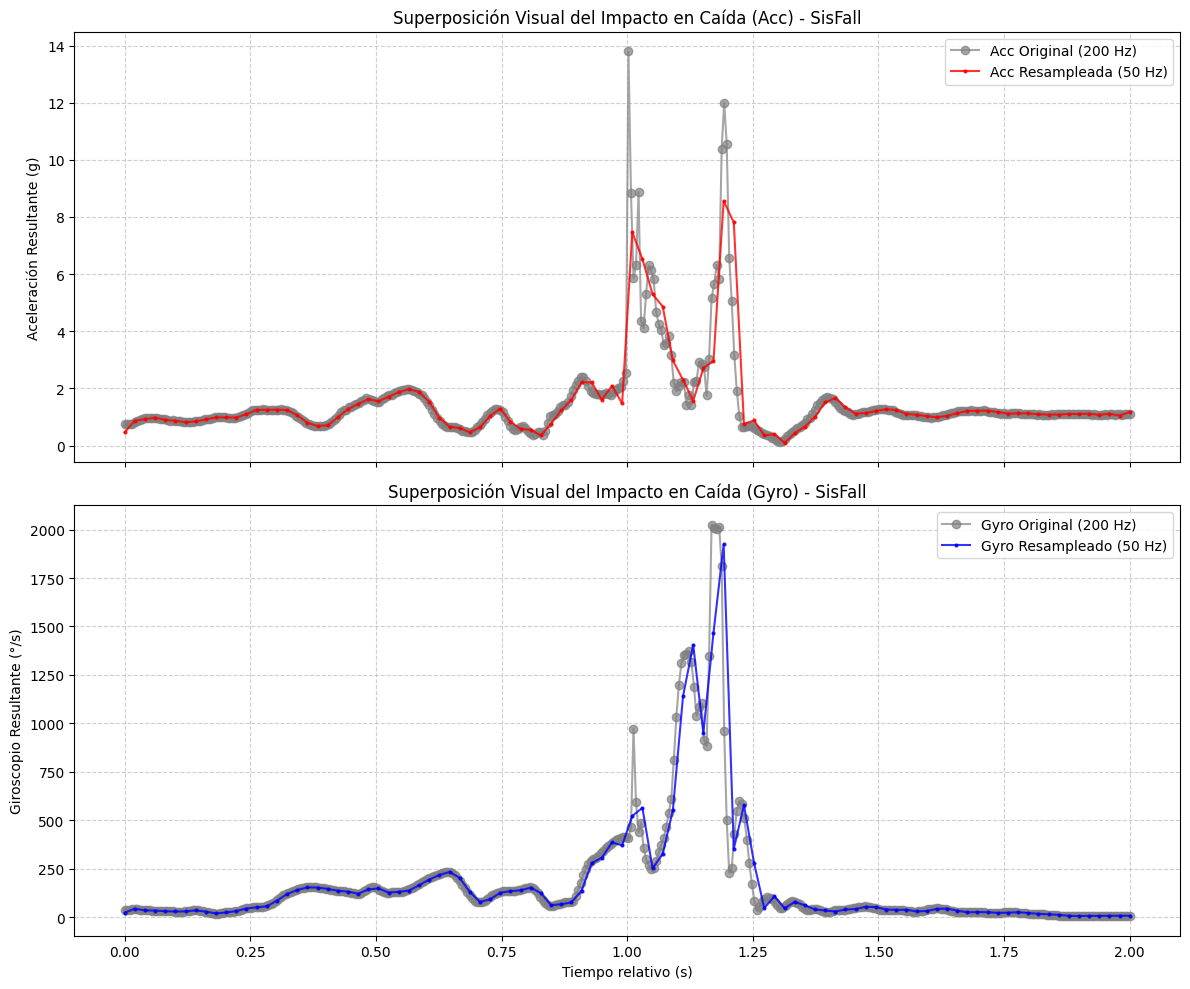

In [ ]:
import matplotlib.pyplot as plt
from scipy.signal import resample_poly, welch

# 1. Obtener una caída de ejemplo
sf_falls = df_sisfall[df_sisfall['Activity_Label'] == 'Fall']

# Seleccionamos el primer trial que encuentre
sf_ejemplo = sf_falls[['Subject', 'Activity_Code', 'Trial']].drop_duplicates().iloc[0]
sf_trial_data = sf_falls[(sf_falls['Subject'] == sf_ejemplo['Subject']) &
                   (sf_falls['Activity_Code'] == sf_ejemplo['Activity_Code']) &
                   (sf_falls['Trial'] == sf_ejemplo['Trial'])].copy()

# Calculamos la aceleración resultante (AVM)
sf_trial_data['A_res'] = np.sqrt(sf_trial_data['Ax']**2 + sf_trial_data['Ay']**2 + sf_trial_data['Az']**2)

# Calculamos el giroscopio resultante (GVM)
sf_trial_data['G_res'] = np.sqrt(sf_trial_data['Gx']**2 + sf_trial_data['Gy']**2 + sf_trial_data['Gz']**2)

# 2. Aislar ventana de 2 segundos alrededor del impacto (pico)
sf_fs_orig = 200
sf_fs_new = 50

# Encontramos el índice donde ocurre el pico máximo (impacto)
sf_peak_idx = sf_trial_data['A_res'].argmax()

# Tomamos 1 segundo antes y 1 segundo después (200 muestras hacia cada lado)
sf_start_idx = max(0, sf_peak_idx - sf_fs_orig)
sf_end_idx = min(len(sf_trial_data), sf_peak_idx + sf_fs_orig)

# Extraemos las señales de la ventana temporal
sf_window_acc = sf_trial_data['A_res'].iloc[sf_start_idx:sf_end_idx].values
sf_window_gyro = sf_trial_data['G_res'].iloc[sf_start_idx:sf_end_idx].values
sf_t_orig = np.linspace(0, len(sf_window_acc) / sf_fs_orig, len(sf_window_acc))

# Graficar la señal original

# 3. Resamplear a 50 Hz
# Factor de resampleo: down = 4 (200 Hz / 4 = 50 Hz)
sf_window_acc_resampled = resample_poly(sf_window_acc, up=1, down=4)
sf_window_gyro_resampled = resample_poly(sf_window_gyro, up=1, down=4)
sf_t_resampled = np.linspace(0, len(sf_window_acc) / sf_fs_orig, len(sf_window_acc_resampled))

# 4. Graficar la superposición (Dos subplots)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Gráfico 1: Acelerómetro
ax1.plot(sf_t_orig, sf_window_acc, label='Acc Original (200 Hz)', color='gray', alpha=0.7, marker='o')
ax1.plot(sf_t_resampled, sf_window_acc_resampled, label='Acc Resampleada (50 Hz)', color='red', marker='.', markersize=4, alpha=0.8)
ax1.set_title('Superposición Visual del Impacto en Caída (Acc) - SisFall')
ax1.set_ylabel('Aceleración Resultante (g)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# Gráfico 2: Giroscopio
ax2.plot(sf_t_orig, sf_window_gyro, label='Gyro Original (200 Hz)', color='gray', alpha=0.7, marker='o')
ax2.plot(sf_t_resampled, sf_window_gyro_resampled, label='Gyro Resampleado (50 Hz)', color='blue', marker='.', markersize=4, alpha=0.8)
ax2.set_title('Superposición Visual del Impacto en Caída (Gyro) - SisFall')
ax2.set_xlabel('Tiempo relativo (s)')
ax2.set_ylabel('Giroscopio Resultante (°/s)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

> La inspección visual del evento de impacto revela un aplanamiento severo en el vértice de la señal, siendo particularmente crítico en el acelerómetro. Al reducir la frecuencia de 200 Hz a 50 Hz, la resolución temporal disminuye de tal manera que los picos agudos no logran ser capturados. La transformación actúa como un filtro de suavizado muy agresivo, demostrando gráficamente una pérdida sustancial de la amplitud instantánea del evento físico.

>

##### ----- UPFall

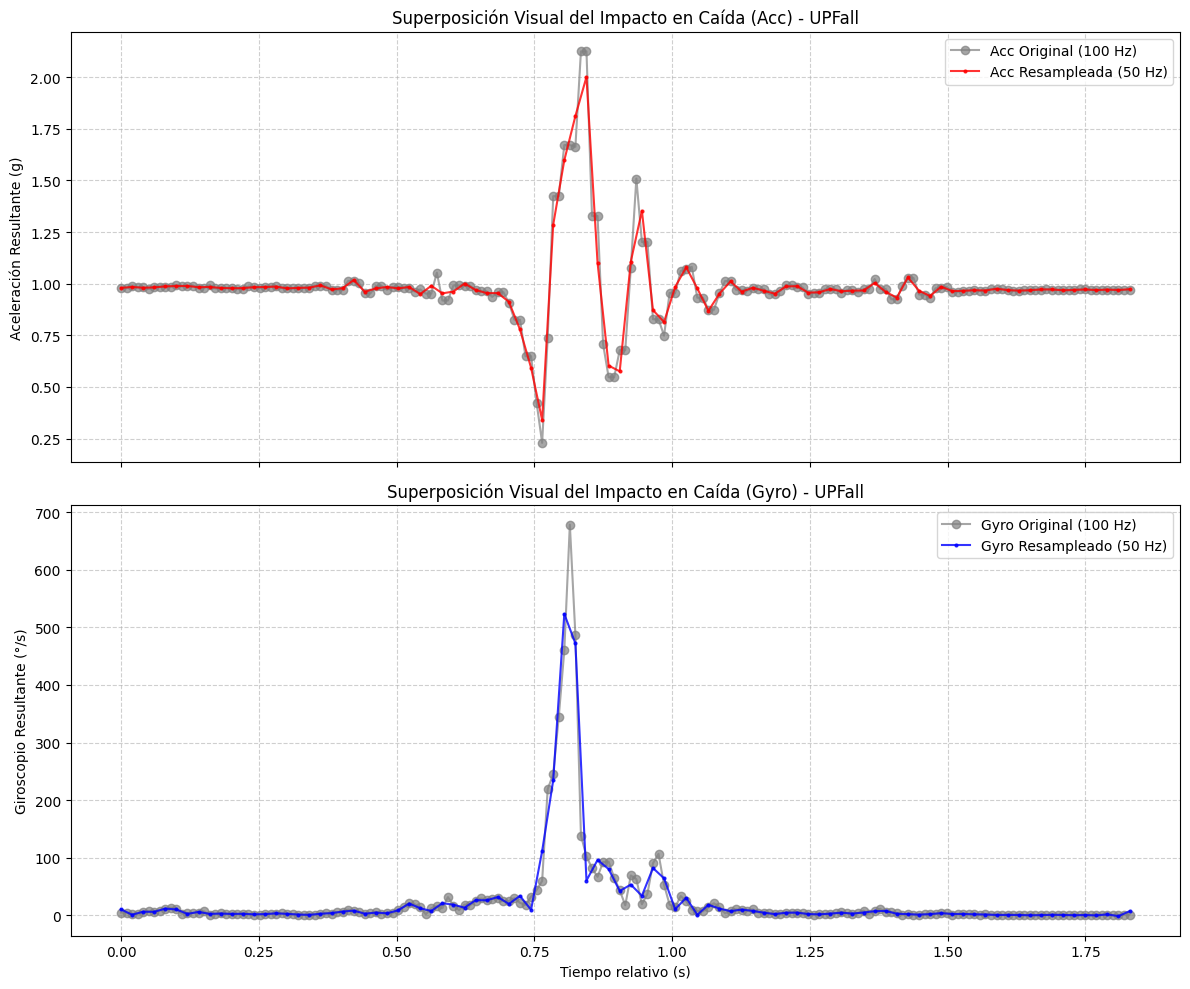

In [10]:
import matplotlib.pyplot as plt
from scipy.signal import resample_poly, welch

# 1. Obtener una caída de ejemplo
up_falls = df_upfall[df_upfall['Activity_Label'] == 'Fall']

# Seleccionamos el primer trial que encuentre
up_ejemplo = up_falls[['Subject', 'Activity_Code', 'Trial']].drop_duplicates().iloc[0]
up_trial_data = up_falls[(up_falls['Subject'] == up_ejemplo['Subject']) &
                   (up_falls['Activity_Code'] == up_ejemplo['Activity_Code']) &
                   (up_falls['Trial'] == up_ejemplo['Trial'])].copy()

# Calculamos la aceleración resultante (AVM)
up_trial_data['A_res'] = np.sqrt(up_trial_data['Ax']**2 + up_trial_data['Ay']**2 + up_trial_data['Az']**2)

# Calculamos el giroscopio resultante (GVM)
up_trial_data['G_res'] = np.sqrt(up_trial_data['Gx']**2 + up_trial_data['Gy']**2 + up_trial_data['Gz']**2)

# 2. Aislar ventana de 2 segundos alrededor del impacto (pico)
up_fs_orig = 100
up_fs_new = 50

# Encontramos el índice donde ocurre el pico máximo (impacto)
up_peak_idx = up_trial_data['A_res'].argmax()

# Tomamos 1 segundo antes y 1 segundo después (200 muestras hacia cada lado)
up_start_idx = max(0, up_peak_idx - up_fs_orig)
up_end_idx = min(len(up_trial_data), up_peak_idx + up_fs_orig)

# Extraemos las señales de la ventana temporal
up_window_acc = up_trial_data['A_res'].iloc[up_start_idx:up_end_idx].values
up_window_gyro = up_trial_data['G_res'].iloc[up_start_idx:up_end_idx].values
up_t_orig = np.linspace(0, len(up_window_acc) / up_fs_orig, len(up_window_acc))

# Graficar la señal original

# 3. Resamplear a 50 Hz
# Factor de resampleo: down = 2 (100 Hz / 2 = 50 Hz)
up_window_acc_resampled = resample_poly(up_window_acc, up=1, down=2, padtype="mean")
up_window_gyro_resampled = resample_poly(up_window_gyro, up=1, down=2, padtype="mean")
up_t_resampled = np.linspace(0, len(up_window_acc) / up_fs_orig, len(up_window_acc_resampled))

# 4. Graficar la superposición (Dos subplots)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Gráfico 1: Acelerómetro
ax1.plot(up_t_orig, up_window_acc, label='Acc Original (100 Hz)', color='gray', alpha=0.7, marker='o')
ax1.plot(up_t_resampled, up_window_acc_resampled, label='Acc Resampleada (50 Hz)', color='red', marker='.', markersize=4, alpha=0.8)
ax1.set_title('Superposición Visual del Impacto en Caída (Acc) - UPFall')
ax1.set_ylabel('Aceleración Resultante (g)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# Gráfico 2: Giroscopio
ax2.plot(up_t_orig, up_window_gyro, label='Gyro Original (100 Hz)', color='gray', alpha=0.7, marker='o')
ax2.plot(up_t_resampled, up_window_gyro_resampled, label='Gyro Resampleado (50 Hz)', color='blue', marker='.', markersize=4, alpha=0.8)
ax2.set_title('Superposición Visual del Impacto en Caída (Gyro) - UPFall')
ax2.set_xlabel('Tiempo relativo (s)')
ax2.set_ylabel('Giroscopio Resultante (°/s)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

> La inspección visual del impacto evidencia claramente el efecto de suavizado inherente a la reducción de resolución temporal. Si bien la curva de aceleración del caso aislado parece mantener su estructura morfológica con una leve atenuación en el vértice, el giroscopio exhibe un recorte drástico. El filtro elimina el comportamiento agudo del giro original, demostrando que los movimientos rotacionales más violentos y veloces del torso pierden su definición instantánea al pasar de 100 Hz a 50 Hz.

#### 2. Comparación de la Densidad Espectral de Potencia (PSD)
* Validar vía `scipy.signal.welch` que la energía por debajo de los 25 Hz en la señal original es idéntica a la energía en la señal de 50 Hz, y documentar la cantidad de energía "perdida" por encima del límite de Nyquist.

##### ----- SisFall

Tamaño de ventana original: 128
Tamaño de ventana resampleada: 32


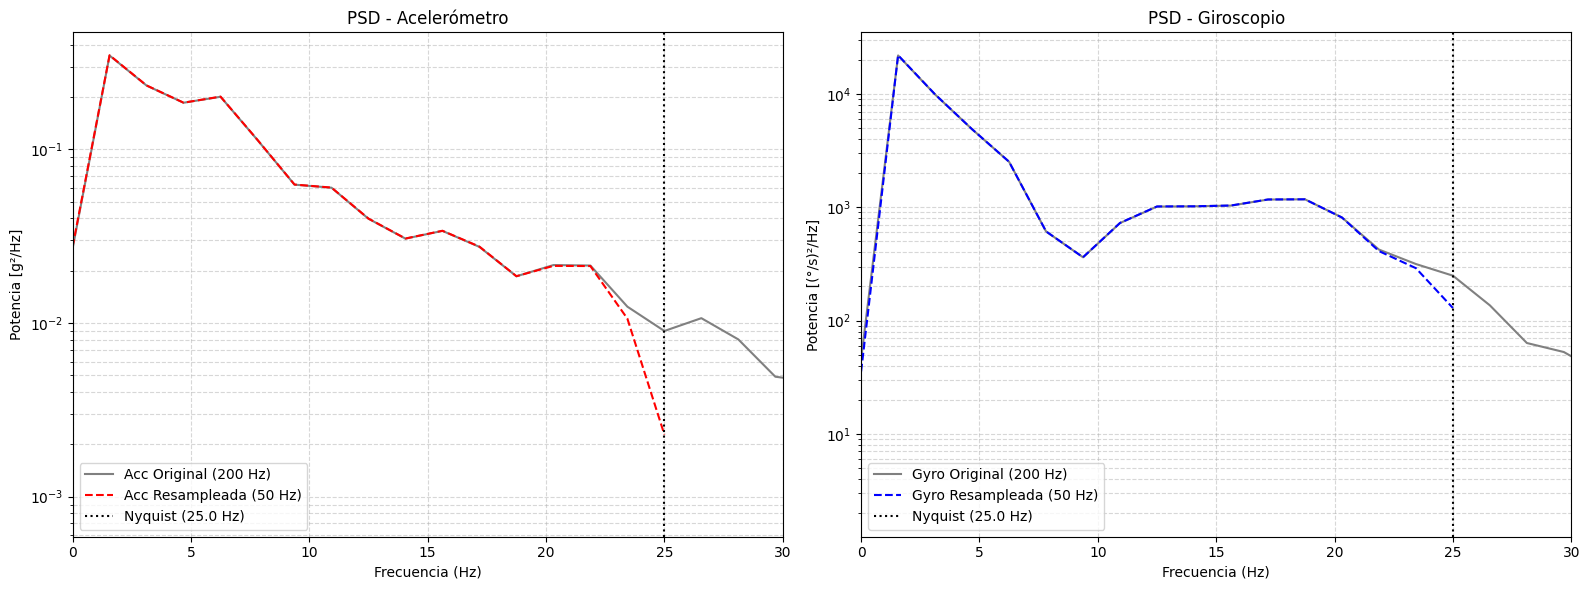

In [ ]:
# 1. Calcular la Densidad Espectral de Potencia (PSD) para Acc y Gyro

# Calcular el tamaño de ventana
target_res = 1.5
sf_nperseg_orig = int(sf_fs_orig / target_res)
sf_nperseg_orig = int(2 ** np.floor(np.log2(sf_nperseg_orig)))

sf_factor_resamp = sf_fs_new / sf_fs_orig
sf_nperseg_resamp = int(sf_nperseg_orig * sf_factor_resamp)
sf_nperseg_resamp = int(2 ** np.round(np.log2(sf_nperseg_resamp)))

print(f"Tamaño de ventana original: {sf_nperseg_orig}")
print(f"Tamaño de ventana resampleada: {sf_nperseg_resamp}")

# PSD para Acelerómetro
sf_f_acc_orig, sf_Pxx_acc_orig = welch(sf_window_acc, fs=sf_fs_orig, nperseg=sf_nperseg_orig)
sf_f_acc_resamp, sf_Pxx_acc_resamp = welch(sf_window_acc_resampled, fs=sf_fs_new, nperseg=sf_nperseg_resamp)

# PSD para Giroscopio
sf_f_gyro_orig, sf_Pxx_gyro_orig = welch(sf_window_gyro, fs=sf_fs_orig, nperseg=sf_nperseg_orig)
sf_f_gyro_resamp, sf_Pxx_gyro_resamp = welch(sf_window_gyro_resampled, fs=sf_fs_new, nperseg=sf_nperseg_resamp)

# 2. Graficar ambas PSDs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico PSD Acelerómetro
ax1.semilogy(sf_f_acc_orig, sf_Pxx_acc_orig, label=f'Acc Original ({sf_fs_orig} Hz)', color='gray')
ax1.semilogy(sf_f_acc_resamp, sf_Pxx_acc_resamp, label=f'Acc Resampleada ({sf_fs_new} Hz)', color='red', linestyle='--')
ax1.axvline(x=sf_fs_new/2, color='black', linestyle=':', label=f'Nyquist ({sf_fs_new/2} Hz)')
ax1.set_title(f'PSD - Acelerómetro')
ax1.set_xlabel('Frecuencia (Hz)')
ax1.set_ylabel('Potencia [g²/Hz]')
ax1.set_xlim(0, sf_fs_new/2 + 5)
ax1.legend()
ax1.grid(True, which="both", linestyle='--', alpha=0.5)

# Gráfico PSD Giroscopio
ax2.semilogy(sf_f_gyro_orig, sf_Pxx_gyro_orig, label=f'Gyro Original ({sf_fs_orig} Hz)', color='gray')
ax2.semilogy(sf_f_gyro_resamp, sf_Pxx_gyro_resamp, label=f'Gyro Resampleada ({sf_fs_new} Hz)', color='blue', linestyle='--')
ax2.axvline(x=sf_fs_new/2, color='black', linestyle=':', label=f'Nyquist ({sf_fs_new/2} Hz)')
ax2.set_title(f'PSD - Giroscopio')
ax2.set_xlabel('Frecuencia (Hz)')
ax2.set_ylabel('Potencia [(°/s)²/Hz]')
ax2.set_xlim(0, sf_fs_new/2 + 5)
ax2.legend()
ax2.grid(True, which="both", linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

> El análisis en el dominio de la frecuencia explica el fenómeno observado en el tiempo. El espectro original demuestra que las caídas en el dataset SisFall poseen una cantidad considerable de energía cinética en bandas de alta frecuencia. La aplicación obligatoria del filtro antialiasing, indispensable para bajar la tasa a 50 Hz, amputa por completo esta información espectral. Queda comprobado que los componentes explosivos y de alta frecuencia de las caídas bruscas son suprimidos de raíz.

##### ----- UPFall

Tamaño de ventana original: 64
Tamaño de ventana resampleada: 32


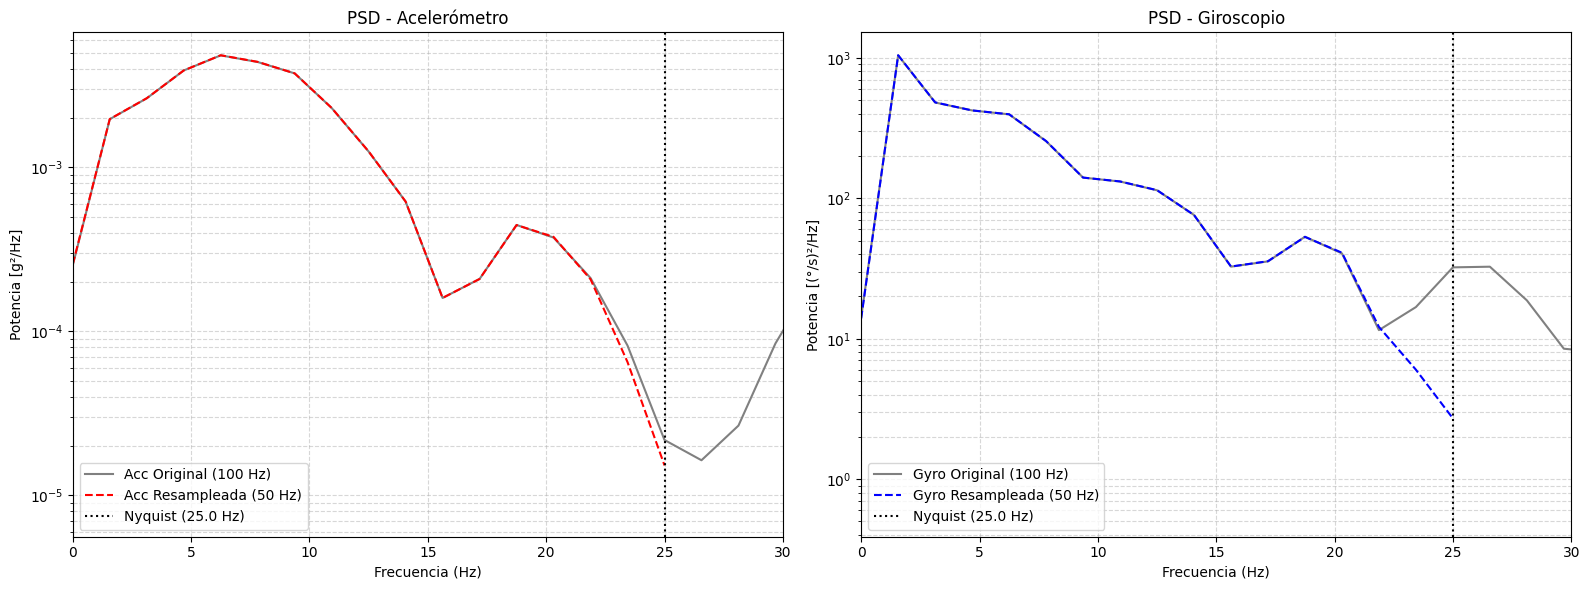

In [ ]:
# 1. Calcular la Densidad Espectral de Potencia (PSD) para Acc y Gyro

# Calcular el tamaño de ventana
target_res = 1.5
up_nperseg_orig = int(up_fs_orig / target_res)
up_nperseg_orig = int(2 ** np.floor(np.log2(up_nperseg_orig)))

up_factor_resamp = up_fs_new / up_fs_orig
up_nperseg_resamp = int(up_nperseg_orig * up_factor_resamp)
up_nperseg_resamp = int(2 ** np.round(np.log2(up_nperseg_resamp)))

print(f"Tamaño de ventana original: {up_nperseg_orig}")
print(f"Tamaño de ventana resampleada: {up_nperseg_resamp}")

# PSD para Acelerómetro
up_f_acc_orig, up_Pxx_acc_orig = welch(up_window_acc, fs=up_fs_orig, nperseg=up_nperseg_orig)
up_f_acc_resamp, up_Pxx_acc_resamp = welch(up_window_acc_resampled, fs=up_fs_new, nperseg=up_nperseg_resamp)

# PSD para Giroscopio
up_f_gyro_orig, up_Pxx_gyro_orig = welch(up_window_gyro, fs=up_fs_orig, nperseg=up_nperseg_orig)
up_f_gyro_resamp, up_Pxx_gyro_resamp = welch(up_window_gyro_resampled, fs=up_fs_new, nperseg=up_nperseg_resamp)

# 2. Graficar ambas PSDs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico PSD Acelerómetro
ax1.semilogy(up_f_acc_orig, up_Pxx_acc_orig, label=f'Acc Original ({up_fs_orig} Hz)', color='gray')
ax1.semilogy(up_f_acc_resamp, up_Pxx_acc_resamp, label=f'Acc Resampleada ({up_fs_new} Hz)', color='red', linestyle='--')
ax1.axvline(x=up_fs_new/2, color='black', linestyle=':', label=f'Nyquist ({up_fs_new/2} Hz)')
ax1.set_title(f'PSD - Acelerómetro')
ax1.set_xlabel('Frecuencia (Hz)')
ax1.set_ylabel('Potencia [g²/Hz]')
ax1.set_xlim(0, up_fs_new/2 + 5)
ax1.legend()
ax1.grid(True, which="both", linestyle='--', alpha=0.5)

# Gráfico PSD Giroscopio
ax2.semilogy(up_f_gyro_orig, up_Pxx_gyro_orig, label=f'Gyro Original ({up_fs_orig} Hz)', color='gray')
ax2.semilogy(up_f_gyro_resamp, up_Pxx_gyro_resamp, label=f'Gyro Resampleada ({up_fs_new} Hz)', color='blue', linestyle='--')
ax2.axvline(x=up_fs_new/2, color='black', linestyle=':', label=f'Nyquist ({up_fs_new/2} Hz)')
ax2.set_title(f'PSD - Giroscopio')
ax2.set_xlabel('Frecuencia (Hz)')
ax2.set_ylabel('Potencia [(°/s)²/Hz]')
ax2.set_xlim(0, up_fs_new/2 + 5)
ax2.legend()
ax2.grid(True, which="both", linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

> El análisis en el dominio de la frecuencia corrobora el recorte observado en el tiempo. La aplicación del filtro antialiasing recorta tajantemente toda la energía espectral contenida entre el nuevo límite de Nyquist (25 Hz) y el original (50 Hz). Queda en evidencia que las caídas en el dataset UPFall poseen un contenido frecuencial importante en esta banda media-alta, el cual es sacrificado por completo para evitar la inyección de frecuencias fantasma en la nueva señal a 50 Hz.

#### 3. Métrica de error máximo
* Calcular la diferencia porcentual entre el valor máximo (pico) de aceleración original y el resampleado.
* Si la diferencia es marginal (ej. $< 5\%$), se justifica cuantitativamente seguir adelante.

##### ----- SisFall

In [ ]:
# 1. Encontrar los picos máximos en ambas señales para Acc y Gyro
sf_max_acc_orig = np.max(sf_window_acc)
sf_max_acc_resamp = np.max(sf_window_acc_resampled)

sf_max_gyro_orig = np.max(sf_window_gyro)
sf_max_gyro_resamp = np.max(sf_window_gyro_resampled)

# 2. Calcular el error porcentual relativo
sf_error_acc_pct = abs(sf_max_acc_orig - sf_max_acc_resamp) / sf_max_acc_orig * 100
sf_error_gyro_pct = abs(sf_max_gyro_orig - sf_max_gyro_resamp) / sf_max_gyro_orig * 100

# 3. Mostrar resultados comparativos
print(f"--- Análisis del Pico de Impacto (Acc) ---")
print(f"Amplitud Pico Original:    {sf_max_acc_orig:.3f} g")
print(f"Amplitud Pico Resampleada: {sf_max_acc_resamp:.3f} g")
print(f"Diferencia porcentual:     {sf_error_acc_pct:.2f} %")

print(f"\n--- Análisis del Pico de Impacto (Gyro) ---")
print(f"Amplitud Pico Original:    {sf_max_gyro_orig:.3f} °/s")
print(f"Amplitud Pico Resampleada: {sf_max_gyro_resamp:.3f} °/s")
print(f"Diferencia porcentual:     {sf_error_gyro_pct:.2f} %")

# Conclusión combinada
umbral = 5.0
if sf_error_acc_pct < umbral and sf_error_gyro_pct < umbral:
    print(f"\n✅ Conclusión: Ambos sensores mantienen el pico con un error menor al {umbral}%. El resampleo es válido.")
else:
    print(f"\n⚠️ Conclusión: Uno de los sensores superó el {umbral}% de atenuación. Evaluar impacto en la detección.")

--- Análisis del Pico de Impacto (Acc) ---
Amplitud Pico Original:    13.796 g
Amplitud Pico Resampleada: 8.565 g
Diferencia porcentual:     37.92 %

--- Análisis del Pico de Impacto (Gyro) ---
Amplitud Pico Original:    2025.097 °/s
Amplitud Pico Resampleada: 1923.679 °/s
Diferencia porcentual:     5.01 %

⚠️ Conclusión: Uno de los sensores superó el 5.0% de atenuación. Evaluar impacto en la detección.


> La evaluación cuantitativa del evento aislado proporciona la primera evidencia de que la transformación es destructiva. Se registró una caída dramática en la aceleración pico, presentando un error porcentual del **37.92%** (reduciendo un impacto de 13.79 g a apenas 8.56 g), destrozando por completo el umbral de tolerancia del 5%. Aunque el giroscopio se mantuvo justo en el límite (5.01%), el aplanamiento del acelerómetro indica que la magnitud absoluta de la caída queda irremediablemente corrompida.

##### ----- UPFall

In [7]:
# 1. Encontrar los picos máximos en ambas señales para Acc y Gyro
up_max_acc_orig = np.max(up_window_acc)
up_max_acc_resamp = np.max(up_window_acc_resampled)

up_max_gyro_orig = np.max(up_window_gyro)
up_max_gyro_resamp = np.max(up_window_gyro_resampled)

# 2. Calcular el error porcentual relativo
up_error_acc_pct = abs(up_max_acc_orig - up_max_acc_resamp) / up_max_acc_orig * 100
up_error_gyro_pct = abs(up_max_gyro_orig - up_max_gyro_resamp) / up_max_gyro_orig * 100

# 3. Mostrar resultados comparativos
print(f"--- Análisis del Pico de Impacto (Acc) ---")
print(f"Amplitud Pico Original:    {up_max_acc_orig:.3f} g")
print(f"Amplitud Pico Resampleada: {up_max_acc_resamp:.3f} g")
print(f"Diferencia porcentual:     {up_error_acc_pct:.2f} %")

print(f"\n--- Análisis del Pico de Impacto (Gyro) ---")
print(f"Amplitud Pico Original:    {up_max_gyro_orig:.3f} °/s")
print(f"Amplitud Pico Resampleada: {up_max_gyro_resamp:.3f} °/s")
print(f"Diferencia porcentual:     {up_error_gyro_pct:.2f} %")

# Conclusión combinada
umbral = 5.0
if up_error_acc_pct < umbral and up_error_gyro_pct < umbral:
    print(f"\n✅ Conclusión: Ambos sensores mantienen el pico con un error menor al {umbral}%. El resampleo es válido.")
else:
    print(f"\n⚠️ Conclusión: Uno de los sensores superó el {umbral}% de atenuación. Evaluar impacto en la detección.")

--- Análisis del Pico de Impacto (Acc) ---
Amplitud Pico Original:    2.124 g
Amplitud Pico Resampleada: 2.001 g
Diferencia porcentual:     5.82 %

--- Análisis del Pico de Impacto (Gyro) ---
Amplitud Pico Original:    677.968 °/s
Amplitud Pico Resampleada: 523.146 °/s
Diferencia porcentual:     22.84 %

⚠️ Conclusión: Uno de los sensores superó el 5.0% de atenuación. Evaluar impacto en la detección.


> La evaluación cuantitativa de este evento aislado muestra un comportamiento dispar pero revelador. Mientras que el pico de aceleración sufre una caída del 5.82% (superando por poco el límite de tolerancia), el giroscopio experimenta una degradación inaceptable del 22.84%. Esto sugiere que, para esta dinámica de caída en particular, el impacto generó un giro de alta frecuencia que el sistema submuestreado es matemáticamente incapaz de registrar, perdiendo más de una quinta parte de su magnitud real.

#### Validación Global

##### ----- SisFall

In [ ]:
# Configuraciones
sf_up_factor = 1
sf_down_factor = 4

sf_errores_acc_pct = []
sf_errores_gyro_pct = []

# Filtrar solo las caídas
sf_trials_unicos = sf_falls[['Subject', 'Activity_Code', 'Trial']].drop_duplicates()

print(f"Iniciando validación global sobre {len(sf_trials_unicos)} caídas...")

for _, row in sf_trials_unicos.iterrows():
    # Extraer el trial específico
    sf_trial_data = sf_falls[(sf_falls['Subject'] == row['Subject']) &
                       (sf_falls['Activity_Code'] == row['Activity_Code']) &
                       (sf_falls['Trial'] == row['Trial'])].copy()

    # Calcular resultantes
    sf_a_res = np.sqrt(sf_trial_data['Ax']**2 + sf_trial_data['Ay']**2 + sf_trial_data['Az']**2).values
    sf_g_res = np.sqrt(sf_trial_data['Gx']**2 + sf_trial_data['Gy']**2 + sf_trial_data['Gz']**2).values

    # Aislar 2 segundos alrededor del pico
    sf_peak_idx = sf_a_res.argmax()
    sf_start_idx = max(0, sf_peak_idx - sf_fs_orig)
    sf_end_idx = min(len(sf_trial_data), sf_peak_idx + sf_fs_orig)

    sf_window_acc = sf_a_res[sf_start_idx:sf_end_idx]
    sf_window_gyro = sf_g_res[sf_start_idx:sf_end_idx]

    # Omitir si la ventana es demasiado pequeña por estar en los bordes
    if len(sf_window_acc) < (sf_fs_orig):
        continue

    # Resamplear
    sf_window_acc_resampled = resample_poly(sf_window_acc, up=sf_up_factor, down=sf_down_factor, padtype= "mean")
    sf_window_gyro_resampled = resample_poly(sf_window_gyro, up=sf_up_factor, down=sf_down_factor, padtype= "mean")

    # Calcular error del pico
    sf_max_acc_orig = np.max(sf_window_acc)
    sf_max_acc_resamp = np.max(sf_window_acc_resampled)
    sf_error_acc = abs(sf_max_acc_orig - sf_max_acc_resamp) / sf_max_acc_orig * 100

    sf_max_gyro_orig = np.max(sf_window_gyro)
    sf_max_gyro_resamp = np.max(sf_window_gyro_resampled)
    sf_error_gyro = abs(sf_max_gyro_orig - sf_max_gyro_resamp) / sf_max_gyro_orig * 100

    sf_errores_acc_pct.append(sf_error_acc)
    sf_errores_gyro_pct.append(sf_error_gyro)

# --- Análisis Estadístico ---
sf_errores_acc_pct = np.array(sf_errores_acc_pct)
sf_errores_gyro_pct = np.array(sf_errores_gyro_pct)

print("\n--- Resultados Globales de Atenuación de Pico (Acelerómetro) ---")
print(f"Error Medio:      {np.mean(sf_errores_acc_pct):.3f} %")
print(f"Error Máximo:     {np.max(sf_errores_acc_pct):.3f} %")
print(f"Percentil 95:     {np.percentile(sf_errores_acc_pct, 95):.3f} %")

print("\n--- Resultados Globales de Atenuación de Pico (Giroscopio) ---")
print(f"Error Medio:      {np.mean(sf_errores_gyro_pct):.3f} %")
print(f"Error Máximo:     {np.max(sf_errores_gyro_pct):.3f} %")
print(f"Percentil 95:     {np.percentile(sf_errores_gyro_pct, 95):.3f} %")

Iniciando validación global sobre 1798 caídas...

--- Resultados Globales de Atenuación de Pico (Acelerómetro) ---
Error Medio:      11.235 %
Error Máximo:     68.666 %
Percentil 95:     46.019 %

--- Resultados Globales de Atenuación de Pico (Giroscopio) ---
Error Medio:      8.083 %
Error Máximo:     72.092 %
Percentil 95:     34.084 %


##### ----- UPFall

In [9]:
# Configuraciones
up_up_factor = 1
up_down_factor = 2

up_errores_acc_pct = []
up_errores_gyro_pct = []

# Filtrar solo las caídas
up_trials_unicos = up_falls[['Subject', 'Activity_Code', 'Trial']].drop_duplicates()

print(f"Iniciando validación global sobre {len(up_trials_unicos)} caídas...")

for _, row in up_trials_unicos.iterrows():
    # Extraer el trial específico
    up_trial_data = up_falls[(up_falls['Subject'] == row['Subject']) &
                       (up_falls['Activity_Code'] == row['Activity_Code']) &
                       (up_falls['Trial'] == row['Trial'])].copy()

    # Calcular resultantes
    up_a_res = np.sqrt(up_trial_data['Ax']**2 + up_trial_data['Ay']**2 + up_trial_data['Az']**2).values
    up_g_res = np.sqrt(up_trial_data['Gx']**2 + up_trial_data['Gy']**2 + up_trial_data['Gz']**2).values

    # Aislar 2 segundos alrededor del pico
    up_peak_idx = up_a_res.argmax()
    up_start_idx = max(0, up_peak_idx - up_fs_orig)
    up_end_idx = min(len(up_trial_data), up_peak_idx + up_fs_orig)

    up_window_acc = up_a_res[up_start_idx:up_end_idx]
    up_window_gyro = up_g_res[up_start_idx:up_end_idx]

    # Omitir si la ventana es demasiado pequeña por estar en los bordes
    if len(up_window_acc) < (up_fs_orig):
        continue

    # Resamplear
    up_window_acc_resampled = resample_poly(up_window_acc, up=up_up_factor, down=up_down_factor, padtype="mean")
    up_window_gyro_resampled = resample_poly(up_window_gyro, up=up_up_factor, down=up_down_factor, padtype="mean")

    # Calcular error del pico
    up_max_acc_orig = np.max(up_window_acc)
    up_max_acc_resamp = np.max(up_window_acc_resampled)
    up_error_acc = abs(up_max_acc_orig - up_max_acc_resamp) / up_max_acc_orig * 100

    up_max_gyro_orig = np.max(up_window_gyro)
    up_max_gyro_resamp = np.max(up_window_gyro_resampled)
    up_error_gyro = abs(up_max_gyro_orig - up_max_gyro_resamp) / up_max_gyro_orig * 100

    up_errores_acc_pct.append(up_error_acc)
    up_errores_gyro_pct.append(up_error_gyro)

# --- Análisis Estadístico ---
up_errores_acc_pct = np.array(up_errores_acc_pct)
up_errores_gyro_pct = np.array(up_errores_gyro_pct)

print("\n--- Resultados Globales de Atenuación de Pico (Acelerómetro) ---")
print(f"Error Medio:      {np.mean(up_errores_acc_pct):.3f} %")
print(f"Error Máximo:     {np.max(up_errores_acc_pct):.3f} %")
print(f"Percentil 95:     {np.percentile(up_errores_acc_pct, 95):.3f} %")

print("\n--- Resultados Globales de Atenuación de Pico (Giroscopio) ---")
print(f"Error Medio:      {np.mean(up_errores_gyro_pct):.3f} %")
print(f"Error Máximo:     {np.max(up_errores_gyro_pct):.3f} %")
print(f"Percentil 95:     {np.percentile(up_errores_gyro_pct, 95):.3f} %")

Iniciando validación global sobre 255 caídas...

--- Resultados Globales de Atenuación de Pico (Acelerómetro) ---
Error Medio:      15.940 %
Error Máximo:     55.604 %
Percentil 95:     40.687 %

--- Resultados Globales de Atenuación de Pico (Giroscopio) ---
Error Medio:      18.200 %
Error Máximo:     61.393 %
Percentil 95:     37.840 %


### **Conclusión**



#### SisFall

La hipótesis planteada al inicio del experimento debe ser rechazada parcialmente. Si bien la reducción a 50 Hz es una obligación arquitectónica para aliviar la carga computacional (MACs) y cumplir con el estricto límite de memoria SRAM del microcontrolador, el supuesto de que la atenuación de los picos se mantendría por debajo del 5% demostró ser incorrecto para las características de este dataset.

El análisis sistemático y masivo sobre 1798 caídas expone la severidad estadística del downsampling desde 200 Hz. Con un error medio del 11.23% en el acelerómetro y extremos en el Percentil 95 que alcanzan un alarmante 46.01% (y 34.08% en la velocidad angular), queda empíricamente demostrado que la información contenida en las fracciones de milisegundo más violentas del choque se pierde de forma irreversible al aplicar el filtro antialiasing. Las caídas fuertes en SisFall son eventos de alta frecuencia que el sistema a 50 Hz simplemente es "ciego" para medir en su totalidad.

Veredicto: La estandarización de SisFall a 50 Hz corrompe profunda y sistemáticamente la amplitud máxima del impacto. No obstante, este es un compromiso (trade-off) técnico ineludible para viabilizar el despliegue del modelo en dispositivos de muy bajos recursos (TinyML). Esta drástica atenuación obliga a un cambio de paradigma en el diseño del modelo neuronal: el algoritmo predictivo no podrá depender de umbrales absolutos de impacto, sino que deberá ser capaz de abstraer y generalizar el patrón cinemático y morfológico de la ventana temporal en su conjunto.

#### UPFall

Al igual que en el experimento con SisFall, la hipótesis inicial debe ser rechazada. Aunque reducir la frecuencia de muestreo de 100 Hz a 50 Hz es una medida arquitectónica obligatoria para optimizar el consumo de memoria SRAM y reducir las operaciones matemáticas (MACs) en el microcontrolador, el costo en la fidelidad de los datos es sumamente alto para este conjunto de datos.

La validación masiva sobre las 255 caídas de UPFall revela un panorama estadístico incluso más consistente en su degradación que otros datasets. Con un error medio cercano al 16% en aceleración y 18% en giroscopio, y un Percentil 95 que ronda el 40% en ambos sensores, se demuestra empíricamente que UPFall es un dataset dominado por componentes cinemáticos de alta frecuencia. El proceso de downsampling actúa como una guillotina sobre los vértices de impacto, aplanando sistemáticamente los picos máximos.

Veredicto: La estandarización de UPFall a 50 Hz introduce una distorsión profunda y generalizada en la magnitud absoluta de las caídas. No obstante, al tratarse de un requisito técnico innegociable para el despliegue del sistema integrado, se debe aceptar esta atenuación severa como un compromiso (trade-off) del diseño. Esto refuerza la directriz arquitectónica para el modelo de Inteligencia Artificial: la red neuronal no debe buscar umbrales absolutos de impacto, sino que deberá ser entrenada para reconocer las firmas morfológicas globales y la envolvente del evento, dado que los valores máximos estarán crónicamente subestimados.